In [131]:
# Carga del dataset

import pandas as pd

dataframe = pd.read_csv(
    "../data/sentences.csv.zip",
    index_col=False,
    compression="zip",
)

In [132]:
# Tamaño del dataset

dataframe.shape

(2264, 2)

In [133]:
# Data

dataframe.head()

,phrase,target
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [134]:
# Sentimientos (clases)

dataframe.target.value_counts()

target
neutral     1391
positive     570
negative     303
Name: count, dtype: int64

In [135]:
# Ejemplos de frases positivas

for i in range(5):
    print(dataframe[dataframe.target == "positive"]["phrase"].iloc[i])

For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m 
In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn 
Operating profit rose to EUR 13.1 mn from EUR 8.7 mn in the corresponding period in 2007 representing 7.7 % of net sales 
Operating profit totalled EUR 21.1 mn , up from EUR 18.6 mn in 2007 , representing 9.7 % of net sales 
Finnish Talentum reports its operating profit increased to EUR 20.5 mn in 2005 from EUR 9.3 mn in 2004 , and net sales totaled EUR 103.3 mn , up from EUR 96.4 mn 


In [136]:
# Ejemplos de frases negativas

for i in range(5):
    print(dataframe[dataframe.target == "negative"]["phrase"].iloc[i])

Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a surfeit of up-to-date , gotta-have cars 
Pharmaceuticals group Orion Corp reported a fall in its third-quarter earnings that were hit by larger expenditures on R&D and marketing 
However , the growth margin slowed down due to the financial crisis 
2009 3 February 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR46m in the fourth quarter of 2009 from a year-earlier profit of EUR45m 
( ADPnews ) - Feb 3 , 2010 - Finland-based steel maker Rautaruukki Oyj ( HEL : RTRKS ) , or Ruukki , said today it slipped to a larger-than-expected pretax loss of EUR 46 million ( USD 64.5 m ) in the fourth quarter of 2009 from 


In [137]:
# Ejemplos de frases neutrales

for i in range(5):
    print(dataframe[dataframe.target == "neutral"]["phrase"].iloc[i])

According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing 
At the request of Finnish media company Alma Media 's newspapers , research manager Jari Kaivo-oja at the Finland Futures Research Centre at the Turku School of Economics has drawn up a future scenario for Finland 's national economy by using a model developed by the University of Denver 
STOCK EXCHANGE ANNOUNCEMENT 20 July 2006 1 ( 1 ) BASWARE SHARE SUBSCRIPTIONS WITH WARRANTS AND INCREASE IN SHARE CAPITAL A total of 119 850 shares have been subscribed with BasWare Warrant Program 
A maximum of 666,104 new shares can further be subscribed for by exercising B options under the 2004 stock option plan 
Tiimari operates 194 stores in six countries -- including its core Finnish market -- and generated a turnover of 76.5 mln eur in 2005 


In [138]:
# Particionamiento de los datos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    dataframe.phrase,
    dataframe.target,
    test_size=0.3,
    shuffle=False,
)

In [139]:
# Construcción de la matriz documento-término

from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    lowercase=True,
    analyzer="word",
    token_pattern=r"\b[a-zA-Z]\w+\b",
    stop_words="english",
    max_df=0.99,
    min_df=2,
    binary=True,
)

vectorizer.fit(X_train)

vectorizer.get_feature_names_out()

array(['ab', 'able', 'abp', ..., 'years', 'yesterday', 'yit'],
      shape=(1820,), dtype=object)

In [140]:
# Entrenamiento del modelo

#from sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import GradientBoostingRegressor
#from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier


clf = MLPClassifier()

X_train_vectorized = vectorizer.transform(X_train)

clf.fit(
    X_train_vectorized,
    y_train,
)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


In [141]:
# Evaluación del modelo

from sklearn.metrics import accuracy_score

# Muestra de entrenamiento:

accuracy_score(
    y_true=y_train,
    y_pred=clf.predict(X_train_vectorized),
)

1.0

In [142]:
# Muestra de prueba:

X_test_vectorized = vectorizer.transform(X_test)
predictions = clf.predict(X_test_vectorized)

accuracy_score(
    y_true=y_test,
    y_pred=predictions,
)

0.5411764705882353

Confusion matrix:
[[ 14  73 182]
 [  0 336  47]
 [  0  10  18]]


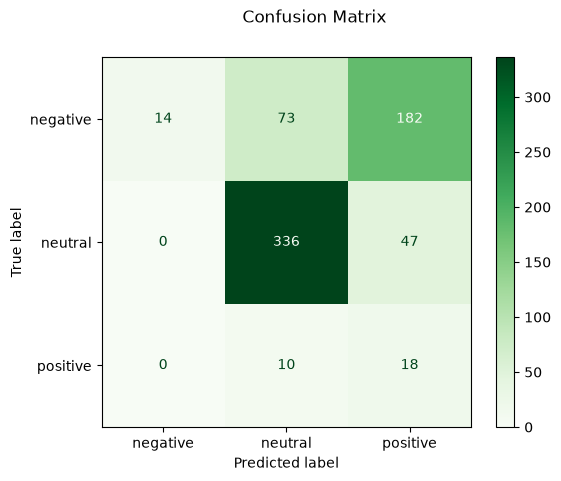

In [143]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    cmap="Greens",
)
disp.figure_.suptitle("Confusion Matrix")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

In [144]:
# Almacenamiento del modelo y del vectorizador

import pickle

with open("../submission/clf.pkl", "wb") as file:
    pickle.dump(clf, file)

with open("../submission/vectorizer.pkl", "wb") as file:
    pickle.dump(vectorizer, file)

In [145]:
# Uso del modelo

with open("../submission/clf.pkl", "rb") as file:
    new_clf = pickle.load(file)

with open("../submission/vectorizer.pkl", "rb") as file:
    new_vectorizer = pickle.load(file)

accuracy_score(
    y_true=dataframe.target,
    y_pred=new_clf.predict(new_vectorizer.transform(dataframe.phrase)),
)

0.8621908127208481